# Expanding-window ML vs rolling 6y — individual then ensemble (MCS, δ=0.999)

Do the tree models improve with **more data**? Test an **expanding window** for XGBoost &
LightGBM (train on all data `[0:r]` up to each refit origin) vs the trailing **6y rolling**
window, on a common OOS that starts at **year 6** (the first expanding window = first 6
years = the rolling window, so they match at the first origin). **HAR stays rolling 6y.**
All models keep recency **δ=0.999**; trees keep the custom-QLIKE objective + 4-fold
walk-forward CV + early stopping + bi-weekly refit (no Optuna).

Reported in two stages: **(1) individual** performance (3 HAR + xgb_roll/lgb_roll +
xgb_exp/lgb_exp), then **(2) ensemble** (equal-weight forecast averages `ens_roll`,
`ens_exp`). Whole program ~4 cores (2 models concurrent × 2 threads).

In [1]:
# ===========================================================================
# Cell 1 — Thread caps, imports, data, constants
# ===========================================================================
import os
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ[_v] = "2"
import importlib.util, subprocess, time, itertools
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

def _import_lightgbm():
    try:
        import lightgbm as lgb; return lgb
    except OSError:
        import sklearn
        sk  = os.path.join(os.path.dirname(sklearn.__file__), ".dylibs")
        lib = os.path.join(os.path.dirname(importlib.util.find_spec("lightgbm").origin),
                           "lib", "lib_lightgbm.dylib")
        subprocess.run(["install_name_tool", "-add_rpath", sk, lib], check=False)
        import lightgbm as lgb; return lgb
lgb = _import_lightgbm()
from arch.bootstrap import MCS

data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW = 6 * TRADING_DAYS                                  # 1512 days = 6y (rolling; expanding warm-up)
DELTA = 0.999                                             # recency for ALL models (HAR + trees)
REFIT_EVERY = 10
EPS = 1e-6
THREADS_PER_MODEL = 2                                     # 2 models concurrent x 2 threads = 4 cores

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"WINDOW={WINDOW} (6y) | DELTA={DELTA} | REFIT_EVERY={REFIT_EVERY} | "
      f"threads/model={THREADS_PER_MODEL} | xgb {xgb.__version__} | lgb {lgb.__version__}")

RV_gold: 4015 obs, 2010-06-08 .. 2026-05-29
WINDOW=1512 (6y) | DELTA=0.999 | REFIT_EVERY=10 | threads/model=2 | xgb 3.2.0 | lgb 4.6.0


In [2]:
# ===========================================================================
# Cell 2 — Design tables
# ===========================================================================
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)
    df["y_level"] = rv.shift(-1)
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])
macro     = data["macro_event"].shift(-1).astype(float)

d_gvz_macro       = build_log_design({"log_GVZ": log_gvz, "macro": macro})
d_crude_gvz_macro = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude, "macro": macro})
d_spx_gvz_macro   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx, "macro": macro})
d_all_macro       = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude,
                                      "log_RV_ES": log_spx, "macro": macro})
for d in (d_crude_gvz_macro, d_spx_gvz_macro, d_all_macro):
    assert d_gvz_macro.index.equals(d.index)
feats_rich = ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "log_RV_ES", "macro"]
print("designs rows:", len(d_gvz_macro), "| rich cols:", list(d_all_macro.columns))

designs rows: 3993 | rich cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'log_RV_ES', 'macro', 'y_log', 'y_level']


In [3]:
# ===========================================================================
# Cell 3 — Helpers + HAR forecasts (rolling 6y, delta=0.999). OOS starts at year 6.
# ===========================================================================
START_DATE = d_gvz_macro.index[WINDOW]   # year-6 gate: expanding ML & rolling HAR match here

def _recency_weights(n, delta):
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]
    w = delta ** ages
    return w * (n / w.sum())

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_log_ols_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA, start_date=None):
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design["y_log"].to_numpy(); idx = design.index; N, p = X.shape
    t_oos = np.arange(window, N)[idx[window:] >= start_date]; starts = t_oos - window
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)[starts].transpose(0, 2, 1)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]
    w = _recency_weights(window, delta); sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]; ys = ywins * sw[None, :]
    beta = np.linalg.solve(np.einsum("nwi,nwj->nij", Xs, Xs), np.einsum("nwi,nw->ni", Xs, ys))
    fitted = np.einsum("nwp,np->nw", Xwins, beta)
    smear = np.einsum("nw,w->n", np.exp(ywins - fitted), w) / w.sum()
    fc = np.exp(np.einsum("np,np->n", X[t_oos], beta)) * smear
    return pd.Series(fc, index=idx[t_oos], name="forecast")

f_har18 = rolling_log_ols_forecast_series(d_gvz_macro,       ["x_d", "x_w", "x_m", "log_GVZ", "macro"])
f_har19 = rolling_log_ols_forecast_series(d_spx_gvz_macro,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "macro"])
f_har20 = rolling_log_ols_forecast_series(d_crude_gvz_macro, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "macro"])
actual = d_gvz_macro["y_level"].reindex(f_har18.index)
print(f"Common OOS: {f_har18.index.min().date()} .. {f_har18.index.max().date()}  (n={len(f_har18)})")
print("HAR mean QLIKE:", {k: round(float(_qlike(actual.values, fv.values)[0].mean()), 6)
                          for k, fv in [("har_run18", f_har18), ("har_run19", f_har19), ("har_run20", f_har20)]})

Common OOS: 2016-07-11 .. 2026-05-28  (n=2481)
HAR mean QLIKE: {'har_run18': 0.027947, 'har_run19': 0.027931, 'har_run20': 0.027866}


In [4]:
# ===========================================================================
# Cell 4 — XGBoost machinery + rolling/expanding forecast fn (custom QLIKE, WF-CV, delta=0.999)
# ===========================================================================
MARGIN_CLIP = (-2.0, 8.0)
ESR, CAP = 30, 500
WF_EDGES = [0.20, 0.40, 0.60, 0.80, 1.00]                  # 4 expanding walk-forward CV folds
XGB_GRID = [dict(max_depth=md, eta=lr, subsample=0.8, colsample_bytree=0.8,
                 min_child_weight=5, reg_lambda=1.0, tree_method="hist", nthread=THREADS_PER_MODEL)
            for md, lr in itertools.product([2, 3, 4], [0.03, 0.1])]

def _xgb_make_obj(w):
    def obj(preds, dtrain):
        y = dtrain.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _xgb_qlike_feval(preds, dmat):
    y = dmat.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0))

def _xgb_fit_window(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]; Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = xgb.DMatrix(Xtr, label=ytr); dtr.set_base_margin(np.full(len(ytr), m0))
        dvl = xgb.DMatrix(Xvl, label=yvl); dvl.set_base_margin(np.full(len(yvl), m0))
        fb = None
        for params in XGB_GRID:
            bst = xgb.train(params, dtr, num_boost_round=CAP, obj=_xgb_make_obj(wtr),
                            custom_metric=_xgb_qlike_feval, evals=[(dvl, "val")],
                            early_stopping_rounds=ESR, maximize=False, verbose_eval=False)
            if fb is None or bst.best_score < fb[0]:
                fb = (bst.best_score, params, bst.best_iteration)
        chosen.append(fb)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = xgb.DMatrix(Xw, label=yw); dall.set_base_margin(np.full(n, m0f))
    boosters = [xgb.train(p, dall, num_boost_round=max(int(bi) + 1, 1),
                          obj=_xgb_make_obj(w_full), verbose_eval=False)
                for (_, p, bi) in chosen]
    return boosters, m0f

def _xgb_predict_ens(boosters, m0f, Xrows):
    fs = []
    for bst in boosters:
        d = xgb.DMatrix(Xrows); d.set_base_margin(np.full(len(Xrows), m0f))
        fs.append(np.exp(np.clip(bst.predict(d), *MARGIN_CLIP)))
    return np.mean(fs, axis=0)

def rolling_xgb_cv_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA,
                                   refit_every=REFIT_EVERY, start_date=None, label="", expanding=False):
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design); t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]
        lo = 0 if expanding else r - window                # expanding: all data [0:r]; rolling: [r-W:r]
        boosters, m0f = _xgb_fit_window(Xall[lo:r], lvl[lo:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _xgb_predict_ens(boosters, m0f, Xall[block])
    print(f"[{label}] done elapsed={time.time()-t0:.0f}s  (expanding={expanding})")
    return pd.Series(fc, index=idx[t_oos], name="forecast")
print("XGB machinery ready.")

XGB machinery ready.


In [5]:
# ===========================================================================
# Cell 5 — LightGBM machinery + rolling/expanding forecast fn (custom QLIKE, WF-CV, delta=0.999)
# ===========================================================================
LGB_DEPTH_LEAVES = [(2, 4), (3, 7), (4, 15)]
LGB_MIN_DATA     = [20, 50, 100]
LGB_GRID = [dict(max_depth=md, num_leaves=nl, min_data_in_leaf=mdl, learning_rate=0.05,
                 feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                 verbosity=-1, num_threads=THREADS_PER_MODEL, seed=0)
            for (md, nl) in LGB_DEPTH_LEAVES for mdl in LGB_MIN_DATA]
LGB_DS = {"feature_pre_filter": False}

def _lgb_make_obj(w):
    def obj(preds, ds):
        y = ds.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _lgb_qlike_feval(preds, ds):
    y = ds.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0)), False

def _lgb_fit_window(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]; Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = lgb.Dataset(Xtr, label=ytr, init_score=np.full(len(ytr), m0),
                          params=LGB_DS, free_raw_data=False)
        dvl = lgb.Dataset(Xvl, label=yvl, init_score=np.full(len(yvl), m0),
                          reference=dtr, params=LGB_DS, free_raw_data=False)
        fb = None
        for params in LGB_GRID:
            bst = lgb.train(dict(params, objective=_lgb_make_obj(wtr)), dtr, num_boost_round=CAP,
                            valid_sets=[dvl], valid_names=["val"], feval=_lgb_qlike_feval,
                            callbacks=[lgb.early_stopping(ESR, verbose=False), lgb.log_evaluation(0)])
            sc = bst.best_score["val"]["qlike"]
            if fb is None or sc < fb[0]:
                fb = (sc, params, bst.best_iteration)
        chosen.append(fb)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = lgb.Dataset(Xw, label=yw, init_score=np.full(n, m0f), params=LGB_DS, free_raw_data=False)
    boosters = [lgb.train(dict(p, objective=_lgb_make_obj(w_full)), dall,
                          num_boost_round=max(int(bi), 1), callbacks=[lgb.log_evaluation(0)])
                for (_, p, bi) in chosen]
    return boosters, m0f

def _lgb_predict_ens(boosters, m0f, Xrows):
    fs = [np.exp(np.clip(m0f + bst.predict(Xrows, raw_score=True), *MARGIN_CLIP)) for bst in boosters]
    return np.mean(fs, axis=0)

def rolling_lgb_cv_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA,
                                   refit_every=REFIT_EVERY, start_date=None, label="", expanding=False):
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design); t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]
        lo = 0 if expanding else r - window
        boosters, m0f = _lgb_fit_window(Xall[lo:r], lvl[lo:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _lgb_predict_ens(boosters, m0f, Xall[block])
    print(f"[{label}] done elapsed={time.time()-t0:.0f}s  (expanding={expanding})")
    return pd.Series(fc, index=idx[t_oos], name="forecast")
print("LGB machinery ready.")

LGB machinery ready.


In [6]:
# ===========================================================================
# Cell 6 — Run the 4 tree models (rolling + expanding), 2 concurrent x 2 threads
# ===========================================================================
jobs = {
    "xgb_roll": (rolling_xgb_cv_forecast_series, dict(expanding=False)),
    "xgb_exp":  (rolling_xgb_cv_forecast_series, dict(expanding=True)),
    "lgb_roll": (rolling_lgb_cv_forecast_series, dict(expanding=False)),
    "lgb_exp":  (rolling_lgb_cv_forecast_series, dict(expanding=True)),
}
t0 = time.time()
with ThreadPoolExecutor(max_workers=2) as ex:
    futs = {n: ex.submit(fn, d_all_macro, feats_rich, label=n, **kw) for n, (fn, kw) in jobs.items()}
    F = {n: futs[n].result() for n in jobs}
print(f"all tree models done in {time.time()-t0:.0f}s")

# Built-in correctness check: at the year-6 start the expanding and rolling training sets
# are identical, so the first REFIT_EVERY forecasts must match exactly.
for lr in ("xgb", "lgb"):
    same = np.allclose(F[f"{lr}_exp"].values[:REFIT_EVERY], F[f"{lr}_roll"].values[:REFIT_EVERY])
    print(f"first-origin {lr}: expanding == rolling for first {REFIT_EVERY} days -> {same}")

[xgb_roll] done elapsed=442s  (expanding=False)


[xgb_exp] done elapsed=500s  (expanding=True)


[lgb_roll] done elapsed=183s  (expanding=False)


[lgb_exp] done elapsed=197s  (expanding=True)
all tree models done in 697s
first-origin xgb: expanding == rolling for first 10 days -> True
first-origin lgb: expanding == rolling for first 10 days -> True


In [7]:
# ===========================================================================
# Cell 7 — INDIVIDUAL performance (MCS #1): 7 models
# ===========================================================================
forecasts = pd.DataFrame({
    "har_run18": f_har18, "har_run19": f_har19, "har_run20": f_har20,
    "xgb_roll": F["xgb_roll"], "lgb_roll": F["lgb_roll"],
    "xgb_exp": F["xgb_exp"], "lgb_exp": F["lgb_exp"],
}).dropna()
act = actual.reindex(forecasts.index).values
losses_ind = pd.DataFrame({m: _qlike(act, forecasts[m].values)[0] for m in forecasts.columns},
                          index=forecasts.index)
assert losses_ind.notna().all().all()
forecasts.to_parquet("expandingml_forecasts.parquet")
losses_ind.to_parquet("expandingml_losses.parquet")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print(f"OOS days: {len(losses_ind)}  ({losses_ind.index.min().date()} .. {losses_ind.index.max().date()})\n")
print("Mean QLIKE (individual, lower=better):")
print(losses_ind.mean().sort_values().rename("mean_qlike").to_frame().to_string())
print("\nExpanding vs rolling (negative = expanding better):")
for lr in ("xgb", "lgb"):
    d = losses_ind[f"{lr}_exp"].mean() - losses_ind[f"{lr}_roll"].mean()
    print(f"  {lr}: exp {losses_ind[f'{lr}_exp'].mean():.6f}  -  roll {losses_ind[f'{lr}_roll'].mean():.6f}  =  {d:+.6f}")

mcs_ind = MCS(losses_ind, size=0.05, reps=10000, block_size=None,
              method="R", bootstrap="stationary", seed=42)
mcs_ind.compute()
res_ind = (pd.DataFrame({"mean_qlike": losses_ind.mean(), "mcs_pvalue": mcs_ind.pvalues["Pvalue"]})
           .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05).sort_values("mean_qlike"))
res_ind.to_parquet("mcs_expandingml_individual.parquet")
print("\n=== Individual MCS ==="); print(res_ind.to_string())
print(f"In 5% MCS: {list(res_ind.index[res_ind['in_mcs']])}")
res_ind

OOS days: 2481  (2016-07-11 .. 2026-05-28)

Mean QLIKE (individual, lower=better):
           mean_qlike
har_run20    0.027866
har_run19    0.027931
har_run18    0.027947
xgb_exp      0.029713
lgb_exp      0.030095
xgb_roll     0.031113
lgb_roll     0.031209

Expanding vs rolling (negative = expanding better):
  xgb: exp 0.029713  -  roll 0.031113  =  -0.001399
  lgb: exp 0.030095  -  roll 0.031209  =  -0.001114



=== Individual MCS ===
           mean_qlike  mcs_pvalue  in_mcs
har_run20    0.027866    1.000000    True
har_run19    0.027931    0.460900    True
har_run18    0.027947    0.460900    True
xgb_exp      0.029713    0.139800    True
lgb_exp      0.030095    0.139800    True
xgb_roll     0.031113    0.139800    True
lgb_roll     0.031209    0.139800    True
In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'xgb_exp', 'lgb_exp', 'xgb_roll', 'lgb_roll']


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027866,1.000000,True
har_run19,0.027931,0.460900,True
har_run18,0.027947,0.460900,True
xgb_exp,0.029713,0.139800,True
lgb_exp,0.030095,0.139800,True
xgb_roll,0.031113,0.139800,True
lgb_roll,0.031209,0.139800,True


In [8]:
# ===========================================================================
# Cell 8 — ENSEMBLE performance (MCS #2): individuals + equal-weight ensembles
# ===========================================================================
# Equal-weight, forecast-level ensembles: HAR(run18) + the two trees (rolling vs expanding).
ens = forecasts.copy()
ens["ens_roll"] = forecasts[["har_run18", "xgb_roll", "lgb_roll"]].mean(axis=1)
ens["ens_exp"]  = forecasts[["har_run18", "xgb_exp",  "lgb_exp"]].mean(axis=1)
losses_ens = pd.DataFrame({m: _qlike(act, ens[m].values)[0] for m in ens.columns}, index=ens.index)

print("Mean QLIKE incl. ensembles (lower=better):")
print(losses_ens.mean().sort_values().rename("mean_qlike").to_frame().to_string())
print(f"\nens_exp {losses_ens['ens_exp'].mean():.6f}  vs  ens_roll {losses_ens['ens_roll'].mean():.6f}"
      f"  =  {losses_ens['ens_exp'].mean() - losses_ens['ens_roll'].mean():+.6f}")

mcs_ens = MCS(losses_ens, size=0.05, reps=10000, block_size=None,
              method="R", bootstrap="stationary", seed=42)
mcs_ens.compute()
res_ens = (pd.DataFrame({"mean_qlike": losses_ens.mean(), "mcs_pvalue": mcs_ens.pvalues["Pvalue"]})
           .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05).sort_values("mean_qlike"))
res_ens.to_parquet("mcs_expandingml_ensemble.parquet")
print("\n=== Ensemble MCS (9 models) ==="); print(res_ens.to_string())
print(f"\nBest: {res_ens.index[0]}")
print(f"In 5% MCS: {list(res_ens.index[res_ens['in_mcs']])}")
res_ens

Mean QLIKE incl. ensembles (lower=better):
           mean_qlike
har_run20    0.027866
har_run19    0.027931
har_run18    0.027947
ens_exp      0.028669
ens_roll     0.029209
xgb_exp      0.029713
lgb_exp      0.030095
xgb_roll     0.031113
lgb_roll     0.031209

ens_exp 0.028669  vs  ens_roll 0.029209  =  -0.000540



=== Ensemble MCS (9 models) ===
           mean_qlike  mcs_pvalue  in_mcs
har_run20    0.027866    1.000000    True
har_run19    0.027931    0.460900    True
har_run18    0.027947    0.460900    True
ens_exp      0.028669    0.273400    True
ens_roll     0.029209    0.206400    True
xgb_exp      0.029713    0.048300   False
lgb_exp      0.030095    0.054700    True
xgb_roll     0.031113    0.065200    True
lgb_roll     0.031209    0.076300    True

Best: har_run20
In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'ens_exp', 'ens_roll', 'lgb_exp', 'xgb_roll', 'lgb_roll']


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027866,1.000000,True
har_run19,0.027931,0.460900,True
har_run18,0.027947,0.460900,True
ens_exp,0.028669,0.273400,True
ens_roll,0.029209,0.206400,True
xgb_exp,0.029713,0.048300,False
lgb_exp,0.030095,0.054700,True
xgb_roll,0.031113,0.065200,True
lgb_roll,0.031209,0.076300,True


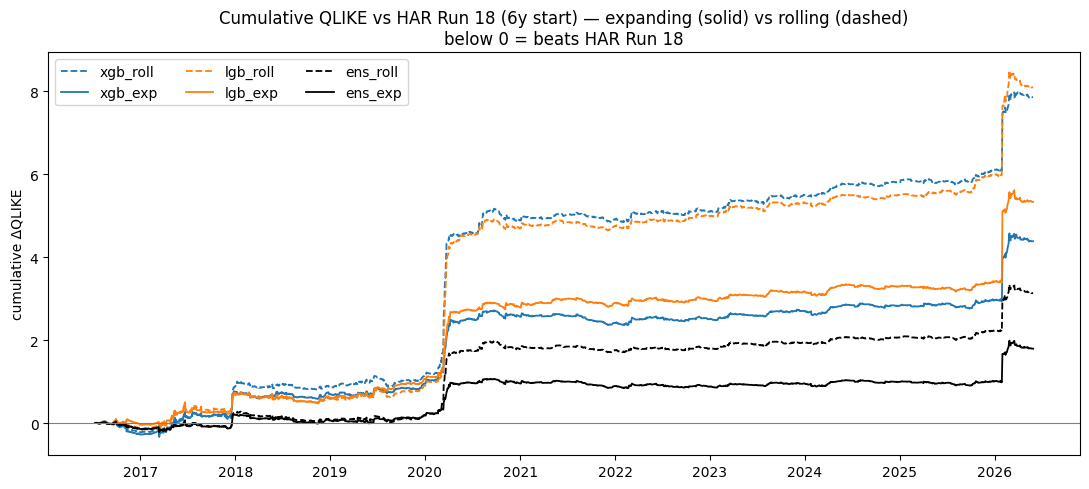

In [9]:
# ===========================================================================
# Cell 9 — Cumulative QLIKE difference vs HAR Run 18 (below 0 = beats run18)
# ===========================================================================
fig, ax = plt.subplots(figsize=(11, 5))
series = [("xgb_roll", "C0", "--"), ("xgb_exp", "C0", "-"),
          ("lgb_roll", "C1", "--"), ("lgb_exp", "C1", "-"),
          ("ens_roll", "k", "--"), ("ens_exp", "k", "-")]
for name, color, ls in series:
    ax.plot(losses_ens.index, (losses_ens[name] - losses_ens["har_run18"]).cumsum(),
            label=f"{name}", color=color, ls=ls, lw=1.3)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Cumulative QLIKE vs HAR Run 18 (6y start) — expanding (solid) vs rolling (dashed)\n"
             "below 0 = beats HAR Run 18")
ax.set_ylabel("cumulative \u0394QLIKE"); ax.legend(ncol=3)
fig.tight_layout(); fig.savefig("expandingml_cum_qlike_6y.png", dpi=150); plt.show()